# 04. Función de transferencia, admitancia y control dinámico

Este cuaderno introduce la función de transferencia de un sistema masa–resorte–amortiguador de un grado de libertad.

El objetivo es comprender:

1. qué es una función de transferencia;
2. qué representa la admitancia dinámica;
3. cómo se calcula $H(\omega)=X(\omega)/F(\omega)$;
4. por qué en baja frecuencia domina la rigidez;
5. por qué en resonancia domina el amortiguamiento;
6. por qué en alta frecuencia domina la masa;
7. cómo cambian magnitud y fase de la respuesta en frecuencia.

Este notebook conecta teoría de vibraciones, análisis en frecuencia y conceptos experimentales usados en análisis modal.

## 1. Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Ambiente listo para estudiar funciones de transferencia")

Ambiente listo para estudiar funciones de transferencia


## 2. Ecuación de movimiento forzada

Para un sistema masa–resorte–amortiguador de un grado de libertad sometido a una fuerza externa \(f(t)\), la ecuación de movimiento es:

$
m\ddot{x}(t)+c\dot{x}(t)+kx(t)=f(t)
$

donde:

- $m$ es la masa;
- $c$ es el coeficiente de amortiguamiento viscoso;
- $k$ es la rigidez;
- $x(t)$ es el desplazamiento;
- $f(t)$ es la fuerza aplicada.

Si analizamos el sistema en frecuencia, usando una excitación armónica, se obtiene:

$
(-m\omega^2 + j c\omega + k)X(\omega)=F(\omega)
$

Por lo tanto, la función de transferencia entre desplazamiento y fuerza es:

$
H(\omega)=\frac{X(\omega)}{F(\omega)}
$

$
H(\omega)=\frac{1}{k-m\omega^2+jc\omega}
$

Esta función se conoce como **admitancia dinámica de desplazamiento por fuerza**.

## 3. Definir parámetros físicos del sistema

Usaremos un sistema simple, similar a los cuadernos anteriores.

In [2]:
# Parámetros físicos
mass = 10.0          # kg
stiffness = 4000.0   # N/m
zeta = 0.04          # razón de amortiguamiento

# Frecuencia natural
omega_n = np.sqrt(stiffness / mass)
fn_hz = omega_n / (2 * np.pi)

# Coeficiente de amortiguamiento viscoso
c = 2 * zeta * mass * omega_n

print(f"Masa m = {mass:.2f} kg")
print(f"Rigidez k = {stiffness:.2f} N/m")
print(f"Razón de amortiguamiento zeta = {zeta:.4f}")
print(f"Coeficiente de amortiguamiento c = {c:.3f} N s/m")
print(f"Frecuencia natural fn = {fn_hz:.3f} Hz")

Masa m = 10.00 kg
Rigidez k = 4000.00 N/m
Razón de amortiguamiento zeta = 0.0400
Coeficiente de amortiguamiento c = 16.000 N s/m
Frecuencia natural fn = 3.183 Hz


## 4. Calcular la admitancia $H(\omega)$

Calcularemos la función:

$
H(\omega)=\frac{1}{k-m\omega^2+jc\omega}
$

Para cada frecuencia, $H(\omega)$ es un número complejo.  
Por eso analizaremos:

- su magnitud $|H(\omega)|$;
- su fase $\angle H(\omega)$.

In [3]:
# Vector de frecuencias
frequencies_hz = np.linspace(0.01, 30, 3000)
omega = 2 * np.pi * frequencies_hz

# Función de transferencia: desplazamiento / fuerza
H = 1 / (stiffness - mass * omega**2 + 1j * c * omega)

H_magnitude = np.abs(H)
H_phase = np.angle(H, deg=True)

# Frecuencia donde la magnitud es máxima
resonance_frequency_hz = frequencies_hz[np.argmax(H_magnitude)]

print(f"Frecuencia natural teórica fn = {fn_hz:.3f} Hz")
print(f"Frecuencia de máximo |H| = {resonance_frequency_hz:.3f} Hz")

Frecuencia natural teórica fn = 3.183 Hz
Frecuencia de máximo |H| = 3.180 Hz


## 5. Magnitud de la función de transferencia

La magnitud $|H(\omega)|$ indica cuánto desplazamiento se produce por unidad de fuerza aplicada.

Cerca de la resonancia, una pequeña fuerza puede producir una gran respuesta.

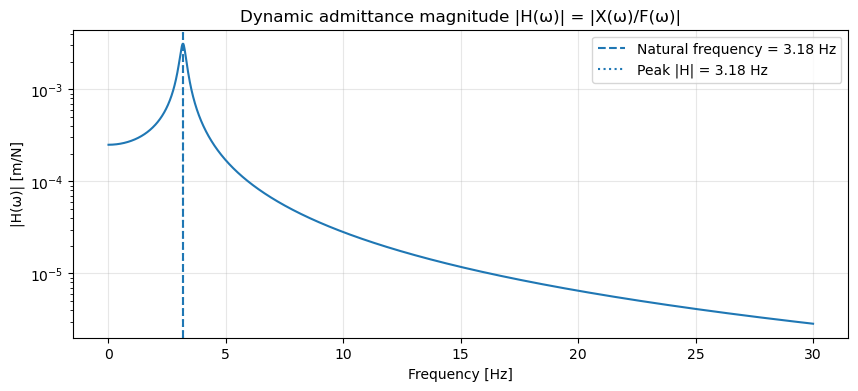

In [4]:
plt.figure(figsize=(10, 4))
plt.semilogy(frequencies_hz, H_magnitude)
plt.axvline(fn_hz, linestyle="--", label=f"Natural frequency = {fn_hz:.2f} Hz")
plt.axvline(resonance_frequency_hz, linestyle=":", label=f"Peak |H| = {resonance_frequency_hz:.2f} Hz")
plt.title("Dynamic admittance magnitude |H(ω)| = |X(ω)/F(ω)|")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H(ω)| [m/N]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Fase de la función de transferencia

La fase muestra el desfase entre la fuerza aplicada y el desplazamiento resultante.

Para un sistema SDOF típico:

- a baja frecuencia, la respuesta está casi en fase con la fuerza;
- cerca de la resonancia, el desfase se acerca a $-90^\circ$;
- a alta frecuencia, el desfase se acerca a $-180^\circ$.

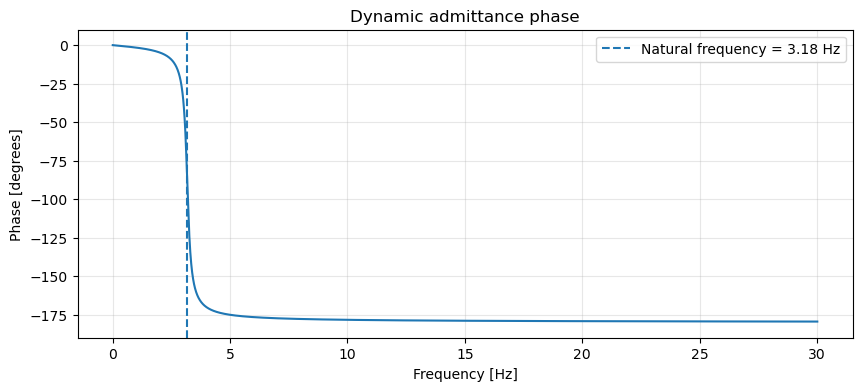

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(frequencies_hz, H_phase)
plt.axvline(fn_hz, linestyle="--", label=f"Natural frequency = {fn_hz:.2f} Hz")
plt.title("Dynamic admittance phase")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [degrees]")
plt.ylim(-190, 10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Interpretación física: control por rigidez, amortiguamiento y masa

La expresión de la función de transferencia es:

$
H(\omega)=\frac{1}{k-m\omega^2+jc\omega}
$

El denominador tiene tres términos:

$
k
$

$
jc\omega
$

$
-m\omega^2
$

Cada término domina en una zona distinta de frecuencia.

### Baja frecuencia: control por rigidez

Cuando $\omega$ es pequeño:

$
m\omega^2 \approx 0
$

$
c\omega \approx 0
$

Entonces:

$
H(\omega) \approx \frac{1}{k}
$

Por eso se dice que en baja frecuencia **la rigidez controla la respuesta**.

### Resonancia: control por amortiguamiento

Cerca de la frecuencia natural:

$
k-m\omega^2 \approx 0
$

Entonces el denominador queda dominado por:

$
jc\omega
$

Por eso, cerca de la resonancia, **el amortiguamiento controla la amplitud máxima**.

### Alta frecuencia: control por masa

Cuando $\omega$ es grande:

$
m\omega^2 \gg k
$

Entonces:

$
H(\omega) \approx \frac{1}{-m\omega^2}
$

Por eso se dice que en alta frecuencia **la masa controla la respuesta**.

## 8. Visualización de las tres zonas de control

Dibujaremos la magnitud de $H(\omega)$ y destacaremos las tres regiones principales:

- zona controlada por rigidez;
- zona controlada por amortiguamiento;
- zona controlada por masa.

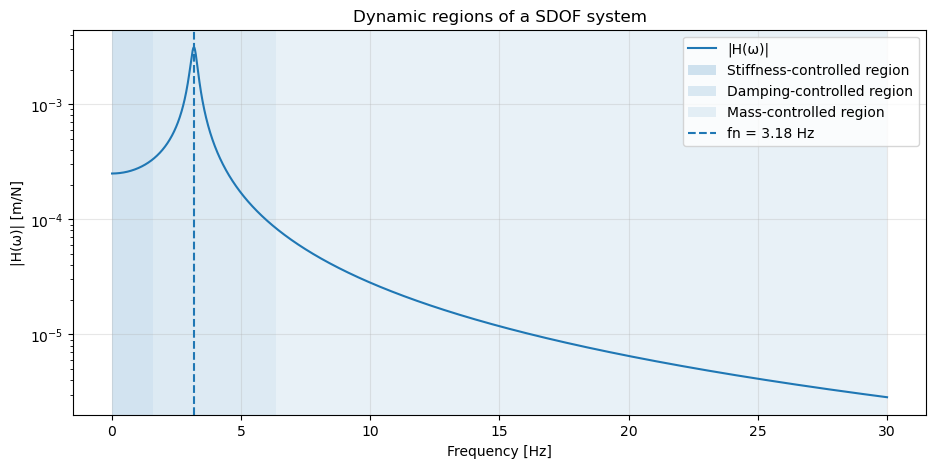

In [6]:
low_freq_limit = 0.5 * fn_hz
high_freq_limit = 2.0 * fn_hz

plt.figure(figsize=(11, 5))
plt.semilogy(frequencies_hz, H_magnitude, label="|H(ω)|")

plt.axvspan(frequencies_hz[0], low_freq_limit, alpha=0.2, label="Stiffness-controlled region")
plt.axvspan(low_freq_limit, high_freq_limit, alpha=0.15, label="Damping-controlled region")
plt.axvspan(high_freq_limit, frequencies_hz[-1], alpha=0.1, label="Mass-controlled region")

plt.axvline(fn_hz, linestyle="--", label=f"fn = {fn_hz:.2f} Hz")

plt.title("Dynamic regions of a SDOF system")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H(ω)| [m/N]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 9. Comparar términos del denominador

Para ver qué término domina en cada región, graficaremos las magnitudes de:

$
|k|
$

$
|c\omega|
$

$
|m\omega^2|
$

Cuando uno de estos términos es mucho mayor que los otros, ese término controla la respuesta dinámica.

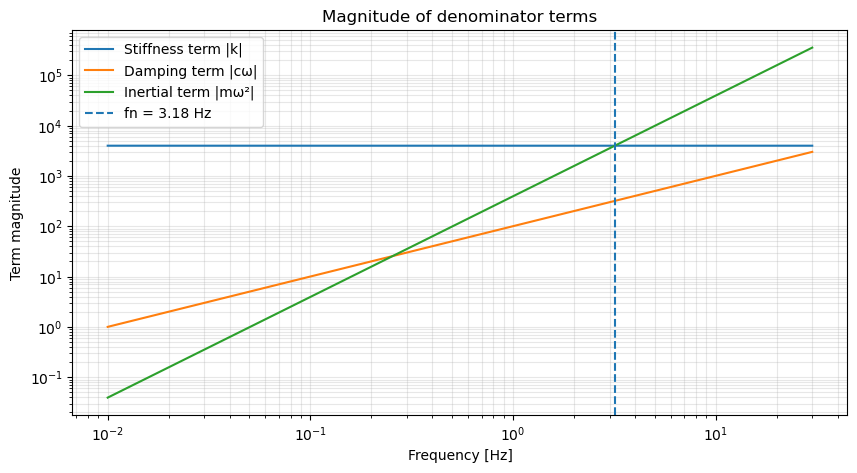

In [7]:
elastic_term = np.ones_like(omega) * stiffness
damping_term = c * omega
inertial_term = mass * omega**2

plt.figure(figsize=(10, 5))
plt.loglog(frequencies_hz, elastic_term, label="Stiffness term |k|")
plt.loglog(frequencies_hz, damping_term, label="Damping term |cω|")
plt.loglog(frequencies_hz, inertial_term, label="Inertial term |mω²|")
plt.axvline(fn_hz, linestyle="--", label=f"fn = {fn_hz:.2f} Hz")

plt.title("Magnitude of denominator terms")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Term magnitude")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## 10. Efecto de cambiar la rigidez

Si aumenta la rigidez:

- la frecuencia natural aumenta;
- la zona de resonancia se desplaza hacia frecuencias más altas;
- la respuesta estática $1/k$ disminuye.

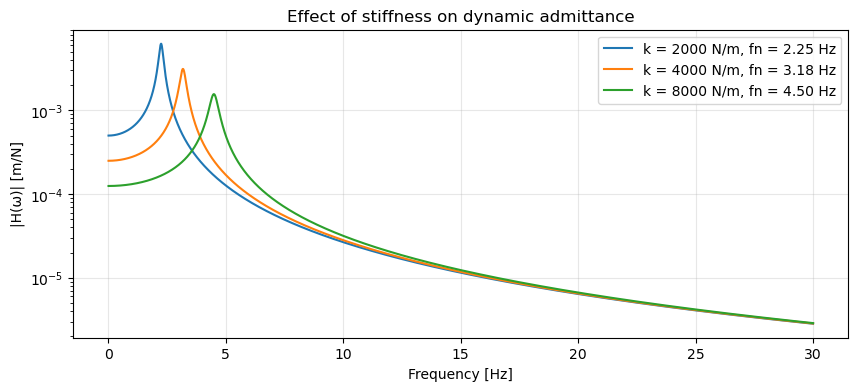

In [8]:
stiffness_values = [2000, 4000, 8000]

plt.figure(figsize=(10, 4))

for k_value in stiffness_values:
    omega_n_local = np.sqrt(k_value / mass)
    fn_local = omega_n_local / (2 * np.pi)
    c_local = 2 * zeta * mass * omega_n_local
    H_local = 1 / (k_value - mass * omega**2 + 1j * c_local * omega)
    plt.semilogy(frequencies_hz, np.abs(H_local), label=f"k = {k_value:.0f} N/m, fn = {fn_local:.2f} Hz")

plt.title("Effect of stiffness on dynamic admittance")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H(ω)| [m/N]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 11. Efecto de cambiar el amortiguamiento

Si aumenta el amortiguamiento:

- el peak de resonancia disminuye;
- la respuesta cerca de la resonancia se vuelve menos pronunciada;
- la frecuencia del máximo puede desplazarse levemente.

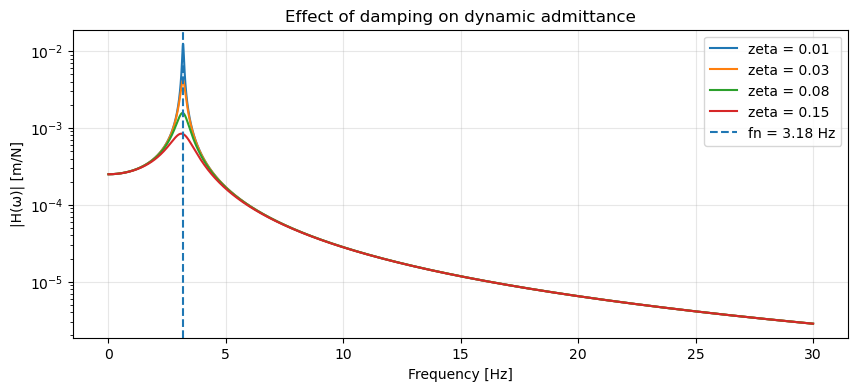

In [9]:
zeta_values = [0.01, 0.03, 0.08, 0.15]

plt.figure(figsize=(10, 4))

for zeta_value in zeta_values:
    c_value = 2 * zeta_value * mass * omega_n
    H_local = 1 / (stiffness - mass * omega**2 + 1j * c_value * omega)
    plt.semilogy(frequencies_hz, np.abs(H_local), label=f"zeta = {zeta_value:.2f}")

plt.axvline(fn_hz, linestyle="--", label=f"fn = {fn_hz:.2f} Hz")
plt.title("Effect of damping on dynamic admittance")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H(ω)| [m/N]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 12. Efecto de cambiar la masa

Si aumenta la masa:

- la frecuencia natural disminuye;
- la zona de resonancia se desplaza hacia frecuencias más bajas;
- la respuesta en alta frecuencia cambia, porque en esa región domina el término $m\omega^2$.

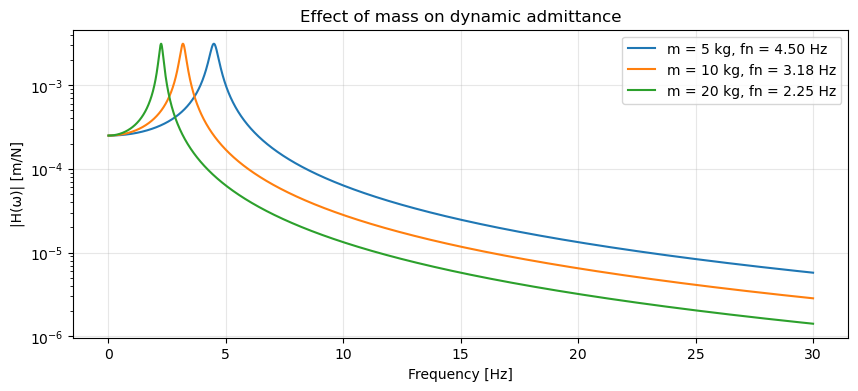

In [10]:
mass_values = [5, 10, 20]

plt.figure(figsize=(10, 4))

for m_value in mass_values:
    omega_n_local = np.sqrt(stiffness / m_value)
    fn_local = omega_n_local / (2 * np.pi)
    c_local = 2 * zeta * m_value * omega_n_local
    H_local = 1 / (stiffness - m_value * omega**2 + 1j * c_local * omega)
    plt.semilogy(frequencies_hz, np.abs(H_local), label=f"m = {m_value:.0f} kg, fn = {fn_local:.2f} Hz")

plt.title("Effect of mass on dynamic admittance")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H(ω)| [m/N]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 13. Otras funciones de respuesta en frecuencia

En este cuaderno usamos:

$
H_x(\omega)=\frac{X(\omega)}{F(\omega)}
$

que corresponde a desplazamiento por fuerza.

Pero también se usan otras FRF:

### Movilidad

$
H_v(\omega)=\frac{V(\omega)}{F(\omega)}
$

Como $V(\omega)=j\omega X(\omega)$, entonces:

$
H_v(\omega)=j\omega H_x(\omega)
$

### Acelerancia

$
H_a(\omega)=\frac{A(\omega)}{F(\omega)}
$

Como $A(\omega)=-\omega^2 X(\omega)$, entonces:

$
H_a(\omega)=-\omega^2 H_x(\omega)
$

En análisis modal experimental es muy común trabajar con acelerancia, porque muchas mediciones se hacen con acelerómetros.

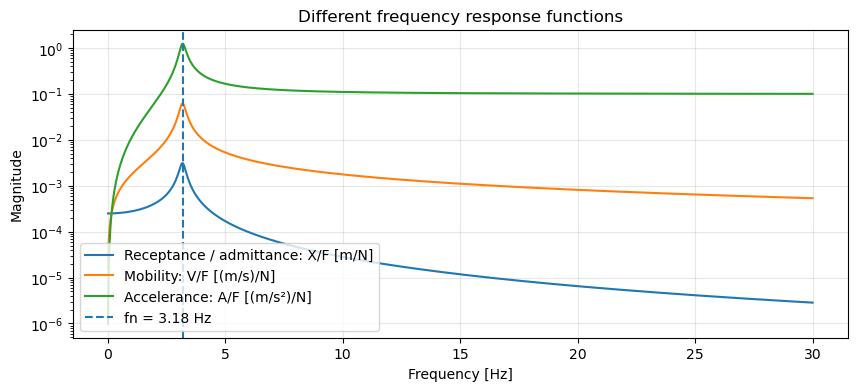

In [11]:
H_displacement = H
H_velocity = 1j * omega * H_displacement
H_acceleration = -(omega**2) * H_displacement

plt.figure(figsize=(10, 4))
plt.semilogy(frequencies_hz, np.abs(H_displacement), label="Receptance / admittance: X/F [m/N]")
plt.semilogy(frequencies_hz, np.abs(H_velocity), label="Mobility: V/F [(m/s)/N]")
plt.semilogy(frequencies_hz, np.abs(H_acceleration), label="Accelerance: A/F [(m/s²)/N]")
plt.axvline(fn_hz, linestyle="--", label=f"fn = {fn_hz:.2f} Hz")
plt.title("Different frequency response functions")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 14. Interpretación

La función de transferencia permite entender cómo responde un sistema ante fuerzas aplicadas a distintas frecuencias.

La idea física clave es:

> la estructura no responde igual a todas las frecuencias.

En baja frecuencia, la fuerza externa produce una respuesta casi estática y domina la rigidez.  
Cerca de la resonancia, la energía se amplifica y el amortiguamiento controla la amplitud máxima.  
En alta frecuencia, la inercia domina y la masa controla la respuesta.

Esta interpretación es central para:

- análisis modal experimental;
- diseño estructural;
- aislamiento de vibraciones;
- monitoreo de salud estructural;
- interpretación de FRF medidas con martillo modal o shaker.

## 15. Preguntas para estudiantes

1. ¿Por qué en baja frecuencia $H(\omega)\approx 1/k$?
2. ¿Qué ocurre con el peak de resonancia si aumenta el amortiguamiento?
3. ¿Qué ocurre con la frecuencia natural si aumenta la rigidez?
4. ¿Qué ocurre con la frecuencia natural si aumenta la masa?
5. ¿Por qué en alta frecuencia domina el término $m\omega^2$?
6. ¿Qué diferencia hay entre receptancia, movilidad y acelerancia?
7. ¿Por qué la acelerancia es tan común en análisis modal experimental?
8. ¿Cómo podríamos medir experimentalmente una FRF usando un martillo modal?

In [ ]:
# Experimento sugerido:
# Cambia mass, stiffness y zeta al inicio del notebook.
# Observa cómo cambian:
# 1. la magnitud de H(ω),
# 2. la fase,
# 3. la frecuencia de resonancia,
# 4. las regiones de control dinámico.